# This file contains two different sections of code.

First we have some Poset code, and some test code to confirm that we have the proper characterizations of Lehmer codes for some abc-avoiding permutations.

Next, we have the six different mappings (alpha, beta, gamma, delta, epsilon, zeta) from Dyck Words to Lehmer codes for abc-avoiding permutations.

alpha = 123 avoiding
beta = 132 avoiding
gamma = 213 avoiding
delta = 231 avoiding
epsilon = 312 avoiding
zeta = 321 avoiding

## Poset Code

In [ ]:
lehmer_map = dict()

# returns (perms, codes)
def get_perm_and_code(n):
    key = n
    if not key in lehmer_map:
        perm = []
        code = []
        for p in Permutations(n):
            perm.append(p)
            code.append(p.to_lehmer_code())

        lehmer_map[key] = (perm, code)

    return lehmer_map[key]

In [45]:
def code_comparator(a,b):
    for x,y in zip(a,b):
        if x > y:
            return False
    return True

In [2]:
ret_val = get_perm_and_code(3)
for x in ret_val:
    print(x)

[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]
[[0, 0, 0], [0, 1, 0], [1, 0, 0], [1, 1, 0], [2, 0, 0], [2, 1, 0]]


## 213 Avoiding

In [28]:
def is_213_avoiding_code(code):
    size = len(code)
    for i in range(size):
        val = code[i]
        for j in range(i+1,size-val):
            if code[i] > code[j]:
                return False

    return True

In [137]:
perm_list, code_list = get_perm_and_code(4)

print(code_list)

avoid_list = []
for p,c in zip(perm_list,code_list):
    #print(p, c, is_213_avoiding_code(c))
    if is_213_avoiding_code(c):
        avoid_list.append(c)
        if not (p.avoids([2,1,3])):
            print('uh oh!', p, c)
    #else:
    #    print('\tnope', c)

print(len(avoid_list))

[[0, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 1, 1, 0], [0, 2, 0, 0], [0, 2, 1, 0], [1, 0, 0, 0], [1, 0, 1, 0], [1, 1, 0, 0], [1, 1, 1, 0], [1, 2, 0, 0], [1, 2, 1, 0], [2, 0, 0, 0], [2, 0, 1, 0], [2, 1, 0, 0], [2, 1, 1, 0], [2, 2, 0, 0], [2, 2, 1, 0], [3, 0, 0, 0], [3, 0, 1, 0], [3, 1, 0, 0], [3, 1, 1, 0], [3, 2, 0, 0], [3, 2, 1, 0]]
14


In [138]:
code_list = [tuple(x) for x in code_list]
avoid_list = [tuple(x) for x in avoid_list]

In [55]:
for c in code_list:
    print(c)

(0, 0, 0, 0)
(0, 0, 1, 0)
(0, 1, 0, 0)
(0, 1, 1, 0)
(0, 2, 0, 0)
(0, 2, 1, 0)
(1, 0, 0, 0)
(1, 0, 1, 0)
(1, 1, 0, 0)
(1, 1, 1, 0)
(1, 2, 0, 0)
(1, 2, 1, 0)
(2, 0, 0, 0)
(2, 0, 1, 0)
(2, 1, 0, 0)
(2, 1, 1, 0)
(2, 2, 0, 0)
(2, 2, 1, 0)
(3, 0, 0, 0)
(3, 0, 1, 0)
(3, 1, 0, 0)
(3, 1, 1, 0)
(3, 2, 0, 0)
(3, 2, 1, 0)


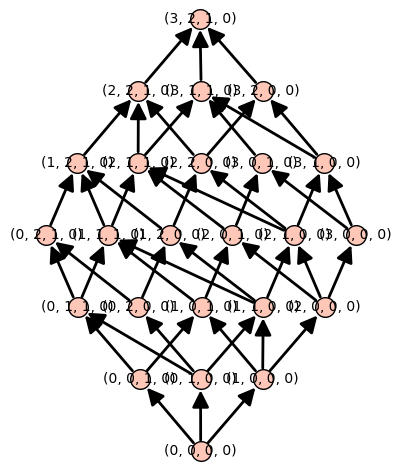

In [139]:
P = Poset((code_list, code_comparator))
P.show()

In [135]:
P.is_lattice()

True

In [58]:
# this is the Bell numbers, Paige's family?
def is_decr_to_zero(code):
    size = len(code)
    for i in range(size-1):
        if code[i] > code[i+1]:
            if code[i+1] > 0:
                return False
    return True

In [62]:
perm_list, code_list = get_perm_and_code(5)

good_code_list = []

for code in code_list:
    if is_decr_to_zero(code):
        good_code_list.append(code)

print(len(good_code_list))


52


In [98]:
# this is https://oeis.org/A091768
def is_incr_to_max(code):
    size = len(code)
    for i in range(size-1):
        if code[i] < code[i+1]:
            #print('checking', code)
            #print('\t', code[i+1], size-i-2)
            if code[i+1] < size - i-2:
                return False
    return True

In [107]:
perm_list, code_list = get_perm_and_code(4)

good_code_list = []

for code in code_list:
    if is_incr_to_max(code):
        #print(code)
        good_code_list.append(tuple(code))

print(len(good_code_list))

22


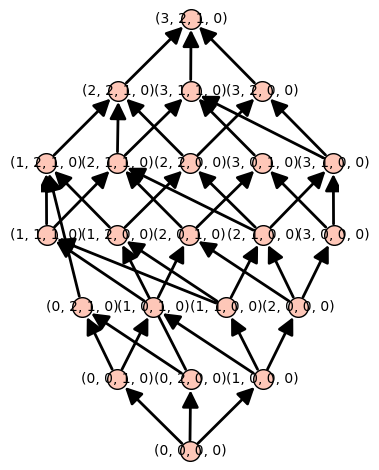

True

In [108]:
P = Poset((good_code_list, code_comparator))
P.show()
P.is_lattice()

## 231 Avoiding

In [111]:
def is_231_avoiding_code(code):
    size = len(code)
    for i in range(size):
        val = code[i]
        for j in range(i+1,i+val+1):
            if code[j] > code[i] - (j-i):
                return False

    return True

In [118]:
perm_list, code_list = get_perm_and_code(4)

good_code_list = []

for code in code_list:
    if is_231_avoiding_code(code):
        good_code_list.append(code)
        print(code)

print(len(good_code_list))

[0, 0, 0, 0]
[0, 0, 1, 0]
[0, 1, 0, 0]
[0, 2, 0, 0]
[0, 2, 1, 0]
[1, 0, 0, 0]
[1, 0, 1, 0]
[2, 0, 0, 0]
[2, 1, 0, 0]
[3, 0, 0, 0]
[3, 0, 1, 0]
[3, 1, 0, 0]
[3, 2, 0, 0]
[3, 2, 1, 0]
14


## 321-avoiding alternate (reverse of 123-avoiding)

In [119]:
def is_321_avoiding_code_alt(code):
    size = len(code)
    for i in range(size):
        val = code[i]
        for j in range(i+1,size):
            if i + code[i] >= j + code[j] :
                if code[j] > 0:
                    return False

    return True

In [123]:
perm_list, code_list = get_perm_and_code(4)

good_code_list = []

for code in code_list:
    if is_321_avoiding_code_alt(code):
        good_code_list.append(code)
        print(code)

print(len(good_code_list))

[0, 0, 0, 0]
[0, 0, 1, 0]
[0, 1, 0, 0]
[0, 1, 1, 0]
[0, 2, 0, 0]
[1, 0, 0, 0]
[1, 0, 1, 0]
[1, 1, 0, 0]
[1, 1, 1, 0]
[1, 2, 0, 0]
[2, 0, 0, 0]
[2, 0, 1, 0]
[2, 2, 0, 0]
[3, 0, 0, 0]
14


In [286]:
dw = DyckWords(3)
for d in dw:
    print(d)
    print('\t', d.returns_to_zero())
    print('\t', d.first_return_decomposition())
        

()()()
	 [2, 4, 6]
	 ([], [1, 0, 1, 0])
()(())
	 [2, 6]
	 ([], [1, 1, 0, 0])
(())()
	 [4, 6]
	 ([1, 0], [1, 0])
(()())
	 [6]
	 ([1, 0, 1, 0], [])
((()))
	 [6]
	 ([1, 1, 0, 0], [])


## delta map takes a Dyck path to a 231 avoiding permutation

In [210]:
# note that this map uses **first return decompostion**, not last return
# this is because sage has first_return_decomposition() function!
# need to update the paper to use the first return decomposition
def dw_delta(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)

        length1 = len(decomp1)
        # note that size1 is one less than the actual size
        size1 = length1/2

        if length1 == 0:
            code1 = [0]
        else:
            code1 = dw_delta(decomp1)
            code1.insert(0, size1)

        if len(decomp2) == 0:
            # primitive
            code = code1
        else:
            code2 = dw_delta(decomp2)
            code = code2 + code1
        return code

In [211]:
def dw_delta_old(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)
        if len(decomp2) == 0:
            #primitive
            code = dw_delta(decomp1)
            code.insert(0,size-1)
        else:
            length1 = len(decomp1)
            # note that size1 is one less than the actual size
            size1 = length1/2

            if length1 == 0:
                code1 = [0]
            else:
                code1 = dw_delta(decomp1)
                code1.insert(0, size1)
            code2 = dw_delta(decomp2)
            code = code2 + code1
        return code

In [330]:
import sage.combinat.permutation as permutation

dw = DyckWords(4)
lehmer_set = set()
for d in dw:
    lehmer = dw_delta(d)
    lehmer_set.add(tuple(lehmer))
    perm = permutation.from_lehmer_code(lehmer)
    print(d, lehmer, perm , perm.avoids([2,3,1]))
print(len(dw), len(lehmer_set))

()()()() [0, 0, 0, 0] [1, 2, 3, 4] True
()()(()) [1, 0, 0, 0] [2, 1, 3, 4] True
()(())() [0, 1, 0, 0] [1, 3, 2, 4] True
()(()()) [2, 0, 0, 0] [3, 1, 2, 4] True
()((())) [2, 1, 0, 0] [3, 2, 1, 4] True
(())()() [0, 0, 1, 0] [1, 2, 4, 3] True
(())(()) [1, 0, 1, 0] [2, 1, 4, 3] True
(()())() [0, 2, 0, 0] [1, 4, 2, 3] True
(()()()) [3, 0, 0, 0] [4, 1, 2, 3] True
(()(())) [3, 1, 0, 0] [4, 2, 1, 3] True
((()))() [0, 2, 1, 0] [1, 4, 3, 2] True
((())()) [3, 0, 1, 0] [4, 1, 3, 2] True
((()())) [3, 2, 0, 0] [4, 3, 1, 2] True
(((()))) [3, 2, 1, 0] [4, 3, 2, 1] True
14 14


## zeta map takes a Dyck path to a 321-avoiding permutation

In [305]:
# note that this map uses first return decompostion, not last return
# need to update the paper to use this decomposition
def dw_zeta(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)

        length1 = len(decomp1)

        if length1 == 0:
            code1 = [0]
        else:
            code1 = dw_zeta(decomp1)
            #print('\tcode1', code1)
            code1.insert(0, 1)

        if len(decomp2) == 0:
            # primitive
            code = code1
        else:
            code2 = dw_zeta(decomp2)
            for idx in range(len(code2)):
                if code2[idx] > 0:
                    code2[idx] = code2[idx] + 1
            code = code2 + code1
        return code

In [331]:
dw = DyckWords(4)
#dw = [ dw[-1]]
lehmer_set = set()
for d in dw:
    lehmer = dw_zeta(d)
    lehmer_set.add(tuple(lehmer))
    perm = permutation.from_lehmer_code(lehmer)
    print(d, lehmer, perm , perm.avoids([3,2,1]), d.to_permutation(map='Knuth'))
print(len(dw), len(lehmer_set))

()()()() [0, 0, 0, 0] [1, 2, 3, 4] True [2, 1, 4, 3]
()()(()) [3, 0, 0, 0] [4, 1, 2, 3] True [2, 4, 1, 3]
()(())() [0, 2, 0, 0] [1, 4, 2, 3] True [2, 1, 3, 4]
()(()()) [2, 0, 0, 0] [3, 1, 2, 4] True [2, 3, 1, 4]
()((())) [2, 2, 0, 0] [3, 4, 1, 2] True [2, 3, 4, 1]
(())()() [0, 0, 1, 0] [1, 2, 4, 3] True [3, 1, 4, 2]
(())(()) [2, 0, 1, 0] [3, 1, 4, 2] True [3, 4, 1, 2]
(()())() [0, 1, 0, 0] [1, 3, 2, 4] True [3, 1, 2, 4]
(()()()) [1, 0, 0, 0] [2, 1, 3, 4] True [1, 3, 2, 4]
(()(())) [1, 2, 0, 0] [2, 4, 1, 3] True [1, 3, 4, 2]
((()))() [0, 1, 1, 0] [1, 3, 4, 2] True [4, 1, 2, 3]
((())()) [1, 0, 1, 0] [2, 1, 4, 3] True [1, 4, 2, 3]
((()())) [1, 1, 0, 0] [2, 3, 1, 4] True [1, 2, 4, 3]
(((()))) [1, 1, 1, 0] [2, 3, 4, 1] True [1, 2, 3, 4]
14 14


In [ ]:
## beta map takes a Dyck path to a 132-avoiding permutation

In [266]:
# note that this map uses first return decompostion, not last return
# need to update the paper to use this decomposition
def dw_beta(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)

        length1 = len(decomp1)
        size1 = length1/2

        if length1 == 0:
            code1 = [0]
        else:
            code1 = dw_beta(decomp1)
            #print('\tcode1', code1)
            code1.insert(0, size1)

        if len(decomp2) == 0:
            # primitive
            code = code1
        else:
            code2 = dw_beta(decomp2)
            #print('\tcode2 before', code2)
            code2 = [x+size1 for x in code2]
            code = code2 + code1
        return code

In [332]:
dw = DyckWords(4)
#dw = [ dw[2]]
lehmer_set = set()
for d in dw:
    lehmer = dw_beta(d)
    lehmer_set.add(tuple(lehmer))
    perm = permutation.from_lehmer_code(lehmer)
    print(d, lehmer, perm, perm.avoids([1,3,2]), d.to_permutation(map='Krattenthaler'))
    #print(d, lehmer)
print(len(dw), len(lehmer_set))

()()()() [0, 0, 0, 0] [1, 2, 3, 4] True [4, 3, 2, 1]
()()(()) [1, 0, 0, 0] [2, 1, 3, 4] True [3, 4, 2, 1]
()(())() [1, 1, 0, 0] [2, 3, 1, 4] True [4, 2, 3, 1]
()(()()) [2, 0, 0, 0] [3, 1, 2, 4] True [3, 2, 4, 1]
()((())) [2, 1, 0, 0] [3, 2, 1, 4] True [2, 3, 4, 1]
(())()() [1, 1, 1, 0] [2, 3, 4, 1] True [4, 3, 1, 2]
(())(()) [2, 1, 1, 0] [3, 2, 4, 1] True [3, 4, 1, 2]
(()())() [2, 2, 0, 0] [3, 4, 1, 2] True [4, 2, 1, 3]
(()()()) [3, 0, 0, 0] [4, 1, 2, 3] True [3, 2, 1, 4]
(()(())) [3, 1, 0, 0] [4, 2, 1, 3] True [2, 3, 1, 4]
((()))() [2, 2, 1, 0] [3, 4, 2, 1] True [4, 1, 2, 3]
((())()) [3, 1, 1, 0] [4, 2, 3, 1] True [3, 1, 2, 4]
((()())) [3, 2, 0, 0] [4, 3, 1, 2] True [2, 1, 3, 4]
(((()))) [3, 2, 1, 0] [4, 3, 2, 1] True [1, 2, 3, 4]
14 14


## epsilon map takes a Dyck path to a 312-avoiding permutation
## appears to be the reverse (left to right) of Bandlow-Killpatrick 
## https://www.combinatorics.org/ojs/index.php/eljc/article/view/v8i1r40/pdf
## process their image columnwise to get Lehmer code (instead of rowwise)

In [281]:
# note that this map uses first return decompostion, not last return
# need to update the paper to use this decomposition
def dw_epsilon(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)

        length1 = len(decomp1)

        if length1 == 0:
            code1 = [0]
        else:
            code1 = dw_epsilon(decomp1)
            #print('\tcode1', code1)
            code1 = [x+1 for x in code1]
            code1.append(0)

        if len(decomp2) == 0:
            # primitive
            code = code1
        else:
            code2 = dw_epsilon(decomp2)
            code = code2 + code1
        return code

In [333]:
dw = DyckWords(4)
#dw = [ dw[2]]
lehmer_set = set()
for d in dw:
    lehmer = dw_epsilon(d)
    lehmer_set.add(tuple(lehmer))
    perm = permutation.from_lehmer_code(lehmer)
    print(d, lehmer, perm, perm.avoids([3,1,2]), d.to_permutation(map='Bandlow-Killpatrick'))
    #print(d, lehmer)
print(len(dw), len(lehmer_set))

()()()() [0, 0, 0, 0] [1, 2, 3, 4] True [1, 2, 3, 4]
()()(()) [1, 0, 0, 0] [2, 1, 3, 4] True [1, 2, 4, 3]
()(())() [0, 1, 0, 0] [1, 3, 2, 4] True [1, 3, 2, 4]
()(()()) [1, 1, 0, 0] [2, 3, 1, 4] True [1, 3, 4, 2]
()((())) [2, 1, 0, 0] [3, 2, 1, 4] True [1, 4, 3, 2]
(())()() [0, 0, 1, 0] [1, 2, 4, 3] True [2, 1, 3, 4]
(())(()) [1, 0, 1, 0] [2, 1, 4, 3] True [2, 1, 4, 3]
(()())() [0, 1, 1, 0] [1, 3, 4, 2] True [2, 3, 1, 4]
(()()()) [1, 1, 1, 0] [2, 3, 4, 1] True [2, 3, 4, 1]
(()(())) [2, 1, 1, 0] [3, 2, 4, 1] True [2, 4, 3, 1]
((()))() [0, 2, 1, 0] [1, 4, 3, 2] True [3, 2, 1, 4]
((())()) [1, 2, 1, 0] [2, 4, 3, 1] True [3, 2, 4, 1]
((()())) [2, 2, 1, 0] [3, 4, 2, 1] True [3, 4, 2, 1]
(((()))) [3, 2, 1, 0] [4, 3, 2, 1] True [4, 3, 2, 1]
14 14


In [ ]:
## gamma map

In [287]:
def dw_gamma(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)

        length1 = len(decomp1)
        size1 = length1/2

        if length1 == 0:
            code1 = [0]
        else:
            code1 = dw_gamma(decomp1)
            #print('\tcode1', code1)
            code1.insert(0, 0)

        if len(decomp2) == 0:
            # primitive
            code = code1
        else:
            code2 = dw_gamma(decomp2)
            #print('\tcode2 before', code2)
            code2 = [x+size1+1 for x in code2]
            code = code2 + code1
        return code

In [334]:
dw = DyckWords(4)
#dw = [ dw[2]]
lehmer_set = set()
for d in dw:
    lehmer = dw_gamma(d)
    lehmer_set.add(tuple(lehmer))
    perm = permutation.from_lehmer_code(lehmer)
    print(d, lehmer, perm, perm.avoids([2,1,3]))
    #print(d, lehmer)
print(len(dw), len(lehmer_set))

()()()() [3, 2, 1, 0] [4, 3, 2, 1] True
()()(()) [2, 2, 1, 0] [3, 4, 2, 1] True
()(())() [3, 1, 1, 0] [4, 2, 3, 1] True
()(()()) [1, 2, 1, 0] [2, 4, 3, 1] True
()((())) [1, 1, 1, 0] [2, 3, 4, 1] True
(())()() [3, 2, 0, 0] [4, 3, 1, 2] True
(())(()) [2, 2, 0, 0] [3, 4, 1, 2] True
(()())() [3, 0, 1, 0] [4, 1, 3, 2] True
(()()()) [0, 2, 1, 0] [1, 4, 3, 2] True
(()(())) [0, 1, 1, 0] [1, 3, 4, 2] True
((()))() [3, 0, 0, 0] [4, 1, 2, 3] True
((())()) [0, 2, 0, 0] [1, 4, 2, 3] True
((()())) [0, 0, 1, 0] [1, 2, 4, 3] True
(((()))) [0, 0, 0, 0] [1, 2, 3, 4] True
14 14


## alpha map takes a Dyck path to a 123-avoiding permutation

In [326]:
def dw_alpha(dw):
    #print('>>>processing', dw)
    length = len(dw)
    
    if length == 2:
        return [0]
    else:
        size = length/2
        decomp1, decomp2 = dw.first_return_decomposition()
        #print('\tdecomp', decomp1, decomp2)

        length1 = len(decomp1)
        size1 = length1/2

        if length1 == 0:
            code1 = [0]
        else:
            code1 = dw_alpha(decomp1)
            code1 = alpha_one(code1)
            code1 = alpha_two(code1)

        if len(decomp2) == 0:
            # primitive
            code = code1
        else:
            code2 = dw_alpha(decomp2)
            #print('code1', decomp1, code1, 'code2', decomp2, code2)
            code2 = [x+size1+1 for x in code2]
            code = code2 + code1
        return code

def alpha_one(code):
    return insert_max_nonflush_digit(code)

def alpha_two(code):
    return rearrange_nonflush_descending(code)


#from n-1 lehmer code, I add the "largest not flush" number to the 2nd position, then form a n lehmer code
def is_flush(c):
    n = len(c)
    for i in range(n - 1):
        val = c[i]
        if val == n - i - 1:
            if all(c[j] >= val for j in range(i)):
                return True
    return False

def insert_max_nonflush_digit(p):
    n = len(p) + 1
    for x in reversed(range(n - 1)):
        new_code = [p[0], x] + p[1:]
        if not is_flush(new_code):
            return new_code
    return None

#this is for rearranging. The rule is: I fix all "top" digits, then I rearrange all non-top digits in a decreasing order.
def rearrange_nonflush_descending(p):
    n = len(p)
    fixed_indices = set()
    #fixed_indices.add(0) I found no need, it's always the largest (haven't prove)
    for i in range(n):
        if p[i] == n - i - 1:
            fixed_indices.add(i)
    to_sort = [p[i] for i in range(n) if i not in fixed_indices]
    to_sort_sorted = sorted(to_sort, reverse=True)
    pnew = []
    j = 0
    for i in range(n):
        if i in fixed_indices:
            pnew.append(p[i])
        else:
            pnew.append(to_sort_sorted[j])
            j += 1
    return pnew

In [335]:
dw = DyckWords(4)
#dw = [ dw[2]]
lehmer_set = set()
for d in dw:
    #print('----processing', d)
    lehmer = dw_alpha(d)
    lehmer_set.add(tuple(lehmer))
    #print('added', d, lehmer)
    perm = permutation.from_lehmer_code(lehmer)
    print(d, lehmer, perm, perm.avoids([1,2,3]))
    #print(d, lehmer)
print(len(dw), len(lehmer_set))

()()()() [3, 2, 1, 0] [4, 3, 2, 1] True
()()(()) [2, 2, 1, 0] [3, 4, 2, 1] True
()(())() [3, 1, 1, 0] [4, 2, 3, 1] True
()(()()) [2, 1, 1, 0] [3, 2, 4, 1] True
()((())) [1, 2, 1, 0] [2, 4, 3, 1] True
(())()() [3, 2, 0, 0] [4, 3, 1, 2] True
(())(()) [2, 2, 0, 0] [3, 4, 1, 2] True
(()())() [3, 1, 0, 0] [4, 2, 1, 3] True
(()()()) [2, 0, 1, 0] [3, 1, 4, 2] True
(()(())) [1, 0, 1, 0] [2, 1, 4, 3] True
((()))() [3, 0, 1, 0] [4, 1, 3, 2] True
((())()) [2, 1, 0, 0] [3, 2, 1, 4] True
((()())) [1, 2, 0, 0] [2, 4, 1, 3] True
(((()))) [0, 2, 1, 0] [1, 4, 3, 2] True
14 14
